In [1]:
using PyPlot
using JLD2
using Statistics
using ProgressBars
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful

In [2]:
pathdir = "Y:/StructuralPhaseTransition/2026/02/11/0001" # Stripes 90°
@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Amplitude_laser τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
@load "Saved_exp_data/ODs_crop_"*join(split(pathdir, "/")[3:end], "_")*".jld2" ODs_dataset
nbr_amp_laser = length(unique(Amplitude_laser))

# Atomic data
Γ = 2.02e8 # In Hz
λ = 421e-9 # In m
ω0 = 2π*ustrip(c_0)/λ
Isat = Γ*ω0^2 / (12*π*ustrip(c_0)^2) # Saturation intensity in photon/m^2

# size_pxl = 0.187e-6;
size_pxl = 0.1966e-6; # New pxl size since 2025/12/31

### Check validity of ROI

Maximum intensity background = 2.726179288829252e22 photon/m^2
Corresponding saturation parameter = 22.842236215080376


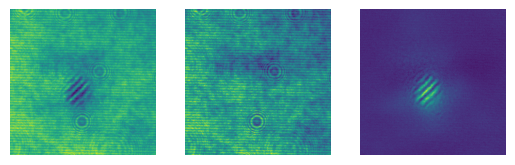

In [3]:
i, j = 19, 1

close("all")
fig, axs = subplots(1, 3)

axs[1].imshow(Imgs_atoms_crop_ds[i, j, :, :])
axs[2].imshow(Imgs_bkg_crop_ds[i, j, :, :])
axs[3].imshow(ODs_dataset[i, j, :, :])

axs[1].axis("off"), axs[2].axis("off"), axs[3].axis("off")

println("Maximum intensity background = $(maximum(Imgs_bkg_crop_ds[i, j, :, :])*0.107 / (0.85 * τ_exp * size_pxl^2)) photon/m^2")
println("Corresponding saturation parameter = $(maximum(Imgs_bkg_crop_ds[i, j, :, :])*0.107 / (0.85 * τ_exp * size_pxl^2 * Isat))")

# pygui(true); show()
pygui(false);

### Intensity integrated over the entire image

In [4]:
Iatoms_img, Ibkg_img, Idark_img = zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2])

if length(τ_exp) == 1
    Convertion_factor = 0.107 / (0.85 * τ_exp)
end

for i = ProgressBar(1:size(Imgs_atoms_crop_ds)[1])
    if length(τ_exp) > 1
        Convertion_factor = 0.107 / (0.85 * τ_exp[i])
    end

    for j = 1:size(Imgs_atoms_crop_ds)[2]
        Iatoms_img[i, j] = sum(Imgs_atoms_crop_ds[i, j, :, :])
        Ibkg_img[i, j] = sum(Imgs_bkg_crop_ds[i, j, :, :])
        Idark_img[i, j] = sum(Imgs_dark_crop_ds[i, j, :, :])
        
        Iatoms_img[i, j] *= Convertion_factor
        Ibkg_img[i, j] *= Convertion_factor
        Idark_img[i, j] *= Convertion_factor
    end
end

# Convert to photons/m^2
S_img = size(Imgs_atoms_crop_ds)[3]*size(Imgs_atoms_crop_ds)[4]*size_pxl^2
Iatoms_img /= S_img
Ibkg_img /= S_img
Idark_img /= S_img;

0.0%┣                                              ┫ 0/19 [00:01<00:-24, -1s/it]
5.3%┣██▎                                        ┫ 1/19 [00:02<Inf:Inf, InfGs/it]
10.5%┣█████                                          ┫ 2/19 [00:02<00:35, 2s/it]
15.8%┣███████▍                                       ┫ 3/19 [00:02<00:18, 1s/it]
21.1%┣██████████                                     ┫ 4/19 [00:03<00:13, 1it/s]
26.3%┣████████████▍                                  ┫ 5/19 [00:03<00:10, 1it/s]
31.6%┣██████████████▉                                ┫ 6/19 [00:03<00:08, 2it/s]
36.8%┣█████████████████▎                             ┫ 7/19 [00:03<00:07, 2it/s]
42.1%┣███████████████████▉                           ┫ 8/19 [00:03<00:05, 2it/s]
47.4%┣██████████████████████▎                        ┫ 9/19 [00:04<00:05, 2it/s]
52.6%┣████████████████████████▏                     ┫ 10/19 [00:04<00:04, 2it/s]
57.9%┣██████████████████████████▋                   ┫ 11/19 [00:04<00:03, 2it/s]
63.2%┣██████████████████████

### Compute mean/std

In [5]:
Mean_atoms, Mean_bkg, Mean_dark, Mean_bkg_atoms = zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser)
Std_atoms, Std_bkg, Std_dark, Std_bkg_atoms = zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser)

for i = 1:size(Imgs_atoms_crop_ds)[1]
    atoms, bkg, dark, bkg_atoms = [], [], [], []
    for j = 1:size(Imgs_atoms_crop_ds)[2]
        push!(atoms, Iatoms_img[i, j]), push!(bkg, Ibkg_img[i, j]), push!(dark, Idark_img[i, j]), push!(bkg_atoms, Ibkg_img[i, j]-Iatoms_img[i, j])
        
    end

    if length(atoms[atoms.>0]) > 0
        Mean_atoms[i], Mean_bkg[i], Mean_dark[i], Mean_bkg_atoms[i] = mean(atoms), mean(bkg), mean(dark), mean(bkg_atoms)
        Std_atoms[i], Std_bkg[i], Std_dark[i], Std_bkg_atoms[i] = std(atoms), std(bkg), std(dark), std(bkg_atoms)
    end
end

In [10]:
@save "Saved_exp_data/Intensity_integrated_all_img_stripes_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Iatoms_img Ibkg_img Idark_img Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms;

In [8]:
@load "Saved_exp_data/Intensity_integrated_all_img_stripes_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Iatoms_img Ibkg_img Idark_img Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms;

### Plot as a function of computed Sat

In [ ]:
close("all")
fig = subplots()

errorbar(Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Bkg-atoms", color="green")
errorbar(Mean_bkg/Isat, Mean_atoms, yerr=Std_atoms, label="Atoms")
errorbar(Mean_bkg/Isat, Mean_bkg, yerr=Std_bkg, label="Bkg")
errorbar(Mean_bkg/Isat, Mean_dark, yerr=Std_dark, label="Dark", color="grey")

for i = 1:size(Iatoms_img)[1]
    for j = 1:size(Iatoms_img)[2]
        scatter(Ibkg_img[i, j]/Isat, Ibkg_img[i, j]-Iatoms_img[i, j], color="g", alpha = 0.1)
        scatter(Ibkg_img[i, j]/Isat, Iatoms_img[i, j], color="b", alpha = 0.1)
        scatter(Ibkg_img[i, j]/Isat, Ibkg_img[i, j], color="r", alpha = 0.1)
        scatter(Ibkg_img[i, j]/Isat, Idark_img[i, j], color="grey")
        scatter(Ibkg_img[i, j]/Isat, Ibkg_img[i, j]-Iatoms_img[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{image}")

legend()

# pygui(true); show();
pygui(false);

In [ ]:
close("all")
fig = subplots()

errorbar(Mean_bkg/Isat, Mean_bkg_atoms, yerr=Std_bkg_atoms, label="Bkg-atoms", color="g")

for i in 1:size(Imgs_atoms_crop_ds)[1]
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        scatter(Ibkg_img[i, j]/Isat, Ibkg_img[i, j]-Iatoms_img[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{image}")

legend()


# pygui(true); show();
pygui(false);